# 🧪 Analíticas de sangre (tabular) — Comparativa multi-arquitectura (v2.1 · CPU · modelo independiente)
## TFM · Módulo Tabular (Laboratorio) · Universidad de Salamanca

---

Versión **más completa y compleja** del módulo tabular. Modelo **independiente** (sin fusión).

## 🆙 Qué cambia respecto a la v1

| Cambio | Detalle |
|---|---|
| **Sin data leakage** | La imputación (mediana) y el estandarizado se ajustan **dentro de cada fold** (solo con su train), nunca con validación. En la v1 se ajustaban sobre todo el train antes de partir → leakage leve en la comparativa. El test final ya era limpio. |
| **Se elimina `cxr_view`** | Describe la radiografía (AP/PA), no es analítica ni contexto del ingreso → no procede en un modelo de laboratorio. |
| **Modelos más pesados** | K=5 folds · XGBoost/LightGBM con más árboles y profundidad · **MLP profundo** (512→256→128) y más épocas · Optuna más amplio (60 trials) para el mejor modelo. |
| **TabPFN preservado** | Se mantiene tu wrapper (monkey-patch + `N_ensemble_configurations`). ⚠️ No se incluye ninguna clave de API en el notebook. |

## 🩺 Decisiones de datos (resumen; el porqué completo, en el informe)

- **Raw para árboles / percentil imputado para densos** (EDA: ΔAUC=0 en árboles; el percentil normaliza para lineal/NN).
- **NaN**: nativo en árboles; imputación **por mediana de train, dentro de cada fold** en densos; + **flags 1/0** de missingness (>2%) por la señal **MNAR**.
- **41 analíticas** completas + contexto clínico (edad, sexo, raza, tipo y lugar de ingreso, horas) — **sin `cxr_view`**.

## 🤖 Arquitecturas (5)

XGBoost · LightGBM · Regresión Logística · **MLP profundo** · **TabPFN** (transformer tabular preentrenado).

## 🩻 Multilabel + No Finding + desequilibrio

Enmascarado + negativos derivados por exclusividad (No Finding) · one-vs-rest enmascarado (árboles/lineal/TabPFN) y
multilabel enmascarado (MLP) · corrección de desequilibrio por etiqueta (`scale_pos_weight`, `class_weight`, `pos_weight`/focal).

## 📊 Salidas

Diagrama de cajas de AUC, matrices de confusión por modelo y del mejor, importancia con nombres legibles,
elección del mejor + **Optuna + entrenamiento final serio + test**. Métrica principal: **AUC-ROC macro**.

## ⏱️ Coste (CPU)

Mayor que la v1 a propósito (K=5, MLP profundo, Optuna amplio, TabPFN con más contexto): **decenas de minutos**.


In [1]:
# CELDA 1 · DEPENDENCIAS
import subprocess, sys
try:
    import torch  # noqa: F401
except ImportError:
    subprocess.run([sys.executable,"-m","pip","install","torch","--index-url","https://download.pytorch.org/whl/cpu","-q"], check=True)
for pkg in ["xgboost","lightgbm","scikit-learn","optuna","pandas","numpy","matplotlib","seaborn","tqdm"]:
    subprocess.run([sys.executable,"-m","pip","install",pkg,"-q"], check=True)
try:
    subprocess.run([sys.executable,"-m","pip","install","tabpfn-client","-q"], check=True); print("tabpfn-client (nube) instalado.")
except Exception as ex:
    print("tabpfn-client no se pudo instalar (se omitirá):", ex)
print("Dependencias instaladas.")


tabpfn-client (nube) instalado.
Dependencias instaladas.


In [2]:
# CELDA 2 · IMPORTS / SEMILLAS / DISPOSITIVO
import os, gc, json, time, copy, random, warnings, functools
from pathlib import Path
from collections import Counter
import numpy as np, pandas as pd, matplotlib.pyplot as plt, seaborn as sns
from tqdm.auto import tqdm
import torch, torch.nn as nn, torch.nn.functional as F
from sklearn.model_selection import KFold
from sklearn.preprocessing import StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (roc_auc_score, average_precision_score, f1_score,
                             confusion_matrix, roc_curve, precision_recall_curve)
import xgboost as xgb
import lightgbm as lgb
import optuna
optuna.logging.set_verbosity(optuna.logging.WARNING); warnings.filterwarnings("ignore")
# TabPFN en la NUBE (tabpfn-client): el cliente ENVÍA los datos de entrenamiento a los servidores de TabPFN.
try:
    import tabpfn_client
    from tabpfn_client import TabPFNClassifier
    _tok = os.environ.get("TABPFN_TOKEN")          # tu token desde variable de entorno (NO lo escribas aquí)
    if _tok:
        try: tabpfn_client.set_access_token(_tok)
        except Exception: pass
    TABPFN_OK = True
except Exception as _e:
    print("tabpfn-client no disponible:", _e); TABPFN_OK = False
SEED=42; random.seed(SEED); np.random.seed(SEED); torch.manual_seed(SEED)
torch.set_num_threads(4); DEVICE=torch.device("cpu")
print(f"xgboost {xgb.__version__} · lightgbm {lgb.__version__} · TabPFN: {TABPFN_OK}")


c:\TFM\1.Opción - Symile Mimic\tfm_multimodal_clinico\venv\lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


xgboost 2.1.4 · lightgbm 4.6.0 · TabPFN: True


In [3]:
# CELDA 3 · RUTAS, ETIQUETAS Y CONSTANTES (v2)
BASE=Path(r"C:\TFM\1.Opción - Symile Mimic\symile-mimic-a-multimodal-clinical-dataset-of-chest-x-rays-electrocardiograms-and-blood-labs-from-mimic-iv-1.0.0")
CSV_DIR=BASE/"data_csv"/"clean"
TRAIN_CSV,VAL_CSV,TEST_CSV=CSV_DIR/"train_clean.csv",CSV_DIR/"val_clean.csv",CSV_DIR/"test_clean.csv"
OUTPUT_DIR=Path("outputs_labs_tabular_v2_1").resolve(); OUTPUT_DIR.mkdir(parents=True,exist_ok=True)
FIG_DIR=OUTPUT_DIR/"figuras"; FIG_DIR.mkdir(parents=True,exist_ok=True)
print("Salidas en:", OUTPUT_DIR)

LABELS=["Atelectasis","Cardiomegaly","Edema","Lung Opacity","No Finding","Pleural Effusion"]
N_LABELS=len(LABELS); NO_FINDING="No Finding"
PATHOLOGY_LABELS=[l for l in LABELS if l!=NO_FINDING]; CORE_LABELS=["Cardiomegaly","Edema","Pleural Effusion"]
DERIVE_NEGATIVES_FROM_EXCLUSIVITY=True
FLAG_THRESH=0.02
K_COMPARE=5                 # v2: 5 folds
OPTUNA_TRIALS_BEST=60       # v2: búsqueda más amplia
USE_TABPFN=TABPFN_OK; TABPFN_MAX=4000; TABPFN_MAX_FINAL=6000

# Contexto clínico (SIN cxr_view: es específico de la imagen)
GENDER_MAP={0:0,1:1,"0":0,"1":1,"M":1,"F":0}
RACE_MAP={"UNKNOWN":0,"WHITE":1,"BLACK":2,"ASIAN":3,"HISPANIC_LATINO":4,"OTHER_KNOWN":0}
ADMISSION_MAP={"SCHEDULED":0,"EMERGENCY":1,"OBSERVATION":2,"URGENT":3}
ADM_LOC_MAP={"EMERGENCY_ROOM":0,"REFERRAL":1,"TRANSFER":2,"INTRA_HOSPITAL":3}
RACE_ONEHOT=5

LAB_MEANING={
 "urea_nitrogen":"función renal/gravedad","albumin":"proteína; baja en efusiones/ICC","rdw":"anisocitosis; fallo cardíaco",
 "creatinine":"función renal","lymphocytes_pct":"inflamación/inmunidad","hemoglobin":"anemia","hematocrit":"anemia",
 "rbc":"masa eritrocitaria","mch":"índice eritrocitario","mchc":"índice eritrocitario","mcv":"índice eritrocitario",
 "nrbc_abs":"estrés medular","pt":"coagulación","inr_pt":"coagulación/hepático","ptt":"coagulación",
 "phosphate":"metabólico","calcium_total":"metabólico","magnesium":"metabólico","sodium":"electrolito/renal",
 "potassium":"electrolito/renal","chloride":"electrolito","bicarbonate":"ácido-base","anion_gap":"ácido-base",
 "base_excess":"ácido-base","ph":"ácido-base","pco2":"gases","po2":"gases","calculated_total_co2":"ácido-base",
 "lactate":"hipoperfusión","glucose":"metabólico","alt":"hepático","ast":"hepático",
 "alkaline_phosphatase":"hepático/óseo","bilirubin_total":"hepático","fibrinogen":"coagulación/inflamación",
 "wbc_count":"inflamación","neutrophils_pct":"inflamación","monocytes_pct":"inmunidad",
 "basophils_pct":"inmunidad","eosinophils_pct":"alergia/inmunidad","platelet_count":"hemostasia"}
def readable(col):
    name,code=col.rsplit("_",1); pretty=name.replace("_"," ").title(); mn=LAB_MEANING.get(name,"")
    return f"{pretty} ({code})"+(f" – {mn}" if mn else "")
print("Constantes listas (sin cxr_view, K=5).")


Salidas en: outputs_labs_tabular_v2_1
Constantes listas (sin cxr_view, K=5).


In [4]:
# CELDA 4 · CARGA DE CSV
df_train=pd.read_csv(TRAIN_CSV,sep=";"); df_val=pd.read_csv(VAL_CSV,sep=";"); df_test=pd.read_csv(TEST_CSV,sep=";")
DEMO=["subject_id","hadm_id","cxr_path","ecg_path","age","gender","race","admission_type",
      "admission_location","cxr_view","hours_adm_to_cxr"]
RAW_LABS=[c for c in df_train.columns if c not in LABELS and c not in DEMO and "pctile" not in c]
PCT_LABS=[c for c in df_train.columns if "pctile" in c]
print(f"train={len(df_train)} val={len(df_val)} test={len(df_test)} | raw={len(RAW_LABS)} percentil={len(PCT_LABS)}")


train=10000 val=750 test=464 | raw=41 percentil=41


In [5]:
# CELDA 5 · OBJETIVOS (masking + negativos derivados)
def build_targets(df,uncertainty_policy="zeros",derive=DERIVE_NEGATIVES_FROM_EXCLUSIVITY,verbose=False):
    raw=df[LABELS].to_numpy(dtype=float); N=raw.shape[0]
    labels=np.zeros((N,N_LABELS),np.float32); mask=np.zeros((N,N_LABELS),np.float32)
    mask[~np.isnan(raw)]=1.0; labels[raw==1]=1.0
    unc=(raw==-1); labels[unc]=1.0 if uncertainty_policy=="ones" else 0.0
    nf=LABELS.index(NO_FINDING); pc=[j for j in range(N_LABELS) if j!=nf]; n_dp=n_dn=n_c=0
    if derive:
        nfp=(raw[:,nf]==1)
        for j in pc:
            f=nfp&np.isnan(raw[:,j]); labels[f,j]=0.0; mask[f,j]=1.0; n_dp+=int(f.sum())
        n_c=int((nfp[:,None]&(raw[:,pc]==1)).sum())
        ap=(raw[:,pc]==1).any(1); fn=ap&np.isnan(raw[:,nf]); labels[fn,nf]=0.0; mask[fn,nf]=1.0; n_dn=int(fn.sum())
    if verbose: print(f"   Neg. derivados patologías={n_dp:,} · No Finding={n_dn:,} · contradicciones={n_c:,}")
    return labels,mask
y_train,m_train=build_targets(df_train,"zeros",verbose=True)
y_val,m_val=build_targets(df_val,"zeros"); y_test,m_test=build_targets(df_test,"zeros")
for j,l in enumerate(LABELS):
    s=m_train[:,j]==1; print(f"   {l:18s} pos={int((y_train[s,j]==1).sum()):5d} neg={int((y_train[s,j]==0).sum()):5d}")


   Neg. derivados patologías=6,091 · No Finding=7,691 · contradicciones=0
   Atelectasis        pos= 2867 neg= 2052
   Cardiomegaly       pos= 3346 neg= 2495
   Edema              pos= 2067 neg= 3735
   Lung Opacity       pos= 3108 neg= 1733
   No Finding         pos= 1368 neg= 7691
   Pleural Effusion   pos= 3618 neg= 3194


In [6]:
# CELDA 6 · FEATURES SIN LEAKAGE (percentil con NaN; imputación/escalado se hacen por fold)
train_miss = df_train[RAW_LABS].isna().mean()
FLAG_LABS = [c for c in RAW_LABS if train_miss[c] > FLAG_THRESH]
print(f"Flags de missingness para {len(FLAG_LABS)}/{len(RAW_LABS)} analíticas (>{FLAG_THRESH*100:.0f}% NaN)")

def build_demo(df):
    # SIN cxr_view. Valores SIN escalar (el escalado se hace por fold).
    N=len(df); cols=[]; names=[]
    cols.append(df["age"].astype(float).to_numpy()[:,None]); names.append("Edad")
    cols.append(df["gender"].map(lambda v:float(GENDER_MAP.get(v,0))).to_numpy()[:,None]); names.append("Sexo")
    def onehot(series,mp,pref):
        M=np.zeros((N,max(mp.values())+1),np.float32)
        for i,v in enumerate(series): M[i,mp.get(str(v).upper(),0)]=1.0
        return M,[f"{pref}={k}" for k,_ in sorted(mp.items(),key=lambda x:x[1])][:M.shape[1]]
    for col,mp,pref in [("race",RACE_MAP,"Raza"),("admission_type",ADMISSION_MAP,"Ingreso"),("admission_location",ADM_LOC_MAP,"Lugar")]:
        M,nm=onehot(df[col],mp,pref); cols.append(M); names+=nm
    cols.append(df["hours_adm_to_cxr"].astype(float).to_numpy()[:,None]); names.append("Horas ingreso→CXR")
    return np.hstack(cols).astype(np.float32), names

DEMO_M_tr,DEMO_NAMES = build_demo(df_train)
def flags(df): return df[FLAG_LABS].isna().astype(np.float32).to_numpy()

def build_tree(df, demo):
    return np.hstack([df[RAW_LABS].to_numpy(np.float32), flags(df), demo])    # raw con NaN (árboles)
def build_dense_raw(df, demo):
    return np.hstack([df[PCT_LABS].to_numpy(np.float32), flags(df), demo])    # percentil con NaN (se imputa por fold)

TREE_tr=build_tree(df_train,DEMO_M_tr); TREE_te=build_tree(df_test,build_demo(df_test)[0]); TREE_vl=build_tree(df_val,build_demo(df_val)[0])
DENSE_tr=build_dense_raw(df_train,DEMO_M_tr); DENSE_te=build_dense_raw(df_test,build_demo(df_test)[0]); DENSE_vl=build_dense_raw(df_val,build_demo(df_val)[0])
TREE_NAMES=[readable(c) for c in RAW_LABS]+[f"falta:{c.rsplit('_',1)[0].replace('_',' ').title()}" for c in FLAG_LABS]+DEMO_NAMES

# Imputación + escalado SIN LEAKAGE: se ajustan sobre los índices de train que se pasen.
def dense_fit(idx):
    imp=SimpleImputer(strategy="median").fit(DENSE_tr[idx])
    sc=StandardScaler().fit(imp.transform(DENSE_tr[idx]))
    return imp,sc
def dense_tx(imp,sc,X): return sc.transform(imp.transform(X)).astype(np.float32)
print(f"TREE={TREE_tr.shape} · DENSE={DENSE_tr.shape} · imputación/escalado se ajustan POR FOLD (sin leakage)")


Flags de missingness para 24/41 analíticas (>2% NaN)
TREE=(10000, 81) · DENSE=(10000, 81) · imputación/escalado se ajustan POR FOLD (sin leakage)


In [7]:
# CELDA 7 · MÉTRICAS MULTILABEL
def multilabel_metrics(probs,labels,mask,thresholds=None):
    if thresholds is None: thresholds={l:0.5 for l in LABELS}
    res={}
    for j,l in enumerate(LABELS):
        s=mask[:,j]==1; yt=labels[s,j]; yp=probs[s,j]; npos=int(yt.sum()); nneg=int((1-yt).sum())
        thr=thresholds.get(l,0.5); pred=(yp>=thr).astype(float)
        if npos>=2 and nneg>=2: auc=roc_auc_score(yt,yp); ap=average_precision_score(yt,yp)
        else: auc=ap=float("nan")
        tp=int(((pred==1)&(yt==1)).sum()); tn=int(((pred==0)&(yt==0)).sum())
        fp=int(((pred==1)&(yt==0)).sum()); fn=int(((pred==0)&(yt==1)).sum())
        res[l]={"AUC":auc,"AP":ap,"F1":f1_score(yt,pred,zero_division=0),"sens":tp/max(tp+fn,1),"spec":tn/max(tn+fp,1),
                "n_pos":npos,"n_neg":nneg,"thr":thr,"TP":tp,"TN":tn,"FP":fp,"FN":fn}
    def mac(g):
        v=[res[l]["AUC"] for l in g if not np.isnan(res[l]["AUC"])]; return float(np.mean(v)) if v else float("nan")
    res["macro_AUC_core"]=mac(CORE_LABELS); res["macro_AUC_path"]=mac(PATHOLOGY_LABELS); return res
def best_thresholds_by_f1(probs,labels,mask,grid=None):
    if grid is None: grid=np.linspace(0.05,0.95,37)
    thr={}
    for j,l in enumerate(LABELS):
        s=mask[:,j]==1; yt=labels[s,j]; yp=probs[s,j]
        if yt.sum()<2: thr[l]=0.5; continue
        bf,bt=-1,0.5
        for t in grid:
            f=f1_score(yt,(yp>=t).astype(float),zero_division=0)
            if f>bf: bf,bt=f,t
        thr[l]=float(bt)
    return thr
print("Métricas listas.")


Métricas listas.


In [8]:
# CELDA 8 · MLP PROFUNDO multilabel enmascarado (v2: 512→256→128)
class MaskedBCE(nn.Module):
    def __init__(s,pos_weight,focal=False,gamma=2.0):
        super().__init__(); s.register_buffer("pw",pos_weight); s.focal=focal; s.g=gamma
    def forward(s,logits,labels,mask):
        pw=s.pw.to(logits.device)
        bce=F.binary_cross_entropy_with_logits(logits,labels,pos_weight=pw,reduction="none")
        if s.focal:
            p=torch.sigmoid(logits); pt=labels*p+(1-labels)*(1-p); bce=((1-pt)**s.g)*bce
        bce=bce*mask; return bce.sum()/mask.sum().clamp(min=1e-8)
class TabMLP(nn.Module):
    def __init__(s,d,hidden=512,dropout=0.3):
        super().__init__()
        h2,h3=hidden//2,hidden//4
        s.net=nn.Sequential(nn.Linear(d,hidden),nn.BatchNorm1d(hidden),nn.ReLU(inplace=True),nn.Dropout(dropout),
                            nn.Linear(hidden,h2),nn.BatchNorm1d(h2),nn.ReLU(inplace=True),nn.Dropout(dropout),
                            nn.Linear(h2,h3),nn.BatchNorm1d(h3),nn.ReLU(inplace=True),nn.Dropout(dropout*0.6),
                            nn.Linear(h3,N_LABELS))
    def forward(s,x): return s.net(x)
def dyn_pos_weight(y,m,clip=10.0):
    w=np.ones(N_LABELS,np.float32)
    for j in range(N_LABELS):
        s=m[:,j]==1; pos=(y[s,j]==1).sum(); neg=(y[s,j]==0).sum(); w[j]=np.clip(neg/max(pos,1),1/clip,clip)
    return torch.tensor(w,dtype=torch.float32)
def train_mlp(Xtr,ytr,mtr,Xva,yva,mva,cfg,epochs=150,patience=15):
    crit=MaskedBCE(dyn_pos_weight(ytr,mtr),focal=cfg.get("focal",False)).to(DEVICE)
    model=TabMLP(Xtr.shape[1],cfg.get("hidden",512),cfg.get("dropout",0.3)).to(DEVICE)
    opt=torch.optim.AdamW(model.parameters(),lr=cfg.get("lr",8e-4),weight_decay=cfg.get("wd",1e-4))
    sched=torch.optim.lr_scheduler.CosineAnnealingLR(opt,T_max=epochs,eta_min=1e-7)
    Xt=torch.tensor(Xtr); Yt=torch.tensor(ytr); Mt=torch.tensor(mtr); n=len(Xt); bs=256
    best,bs_state,wait=-1.0,None,0
    for ep in range(epochs):
        model.train(); perm=torch.randperm(n)
        for i in range(0,n,bs):
            idx=perm[i:i+bs]
            if len(idx)<2: continue
            opt.zero_grad(); loss=crit(model(Xt[idx].to(DEVICE)),Yt[idx].to(DEVICE),Mt[idx].to(DEVICE))
            loss.backward(); torch.nn.utils.clip_grad_norm_(model.parameters(),1.0); opt.step()
        sched.step()
        with torch.no_grad():
            model.eval(); pv=torch.sigmoid(model(torch.tensor(Xva).to(DEVICE))).cpu().numpy()
        sc=multilabel_metrics(pv,yva,mva)["macro_AUC_path"]
        if not np.isnan(sc) and sc>best+1e-4: best,bs_state,wait=sc,copy.deepcopy(model.state_dict()),0
        else:
            wait+=1
            if wait>=patience: break
    if bs_state is not None: model.load_state_dict(bs_state)
    with torch.no_grad():
        model.eval(); pv=torch.sigmoid(model(torch.tensor(Xva).to(DEVICE))).cpu().numpy()
    return model, pv
print("MLP profundo listo.")


MLP profundo listo.


In [9]:
# CELDA 9 · One-vs-rest enmascarado + modelos (v2: configs más pesadas)
def ovr_fit_predict(make_clf, Xtr, ytr, mtr, Xva, use_spw=True):
    probs=np.full((len(Xva),N_LABELS),0.5,np.float32)
    for j in range(N_LABELS):
        sel=mtr[:,j]==1; Xj=Xtr[sel]; yj=ytr[sel,j]
        if len(np.unique(yj))<2:
            probs[:,j]=float(yj.mean()) if len(yj) else 0.5; continue
        spw=(yj==0).sum()/max((yj==1).sum(),1)
        clf=make_clf(spw if use_spw else None); clf.fit(Xj,yj); probs[:,j]=clf.predict_proba(Xva)[:,1]
    return probs
def make_xgb(spw,cfg=None):
    p=dict(n_estimators=800,max_depth=5,learning_rate=0.03,subsample=0.8,colsample_bytree=0.8,
           min_child_weight=2,reg_lambda=1.5,tree_method="hist",eval_metric="logloss",n_jobs=4,random_state=SEED)
    if cfg: p.update(cfg)
    return xgb.XGBClassifier(scale_pos_weight=spw,**p)
def make_lgb(spw,cfg=None):
    p=dict(n_estimators=800,num_leaves=63,learning_rate=0.03,subsample=0.8,colsample_bytree=0.8,
           min_child_samples=20,reg_lambda=1.5,n_jobs=4,random_state=SEED,verbosity=-1)
    if cfg: p.update(cfg)
    return lgb.LGBMClassifier(scale_pos_weight=spw,**p)
def make_logreg(spw,cfg=None):
    C=(cfg or {}).get("C",1.0)
    return LogisticRegression(max_iter=3000,class_weight="balanced",C=C,n_jobs=4)

# ⚠️ TabPFN: wrapper de PERSONALIZACIÓN. Si usas el cliente/nube con tu CLAVE DE API,
#    mantén aquí TU configuración y NO incluyas la clave en el notebook (usa una variable
#    de entorno, p.ej. os.environ["TABPFN_TOKEN"]). Aquí se preserva el monkey-patch local.
def make_tabpfn(spw=None, n_ens=4):
    # Cliente de NUBE (tabpfn-client): sin device/N_ensemble_configurations/monkey-patch.
    # ENVÍA los datos a los servidores de TabPFN (requiere token, ver celda 2).
    return TabPFNClassifier()

def predict_model(name, tr, va, Xd_tr, Xd_va):
    if name=="XGBoost":  return ovr_fit_predict(lambda spw: make_xgb(spw), TREE_tr[tr], y_train[tr], m_train[tr], TREE_tr[va])
    if name=="LightGBM": return ovr_fit_predict(lambda spw: make_lgb(spw), TREE_tr[tr], y_train[tr], m_train[tr], TREE_tr[va])
    if name=="LogReg":   return ovr_fit_predict(lambda spw: make_logreg(spw), Xd_tr, y_train[tr], m_train[tr], Xd_va, use_spw=False)
    if name=="MLP":
        _,pv=train_mlp(Xd_tr,y_train[tr],m_train[tr],Xd_va,y_train[va],m_train[va],{"lr":8e-4,"dropout":0.3}); return pv
    if name=="TabPFN":
        if len(tr)<=TABPFN_MAX: Xt,yt,mt=Xd_tr,y_train[tr],m_train[tr]
        else:
            pos=np.random.RandomState(SEED).choice(len(tr),TABPFN_MAX,replace=False); Xt,yt,mt=Xd_tr[pos],y_train[tr][pos],m_train[tr][pos]
        return ovr_fit_predict(lambda spw: make_tabpfn(spw,4), Xt, yt, mt, Xd_va, use_spw=False)
    raise ValueError(name)
print("Modelos (v2) listos.")


Modelos (v2) listos.


In [10]:
# CELDA 10 · COMPARATIVA K-FOLD (robusta: si un modelo falla -p.ej. TabPFN-, se OMITE)
MODELS=["XGBoost","LightGBM","LogReg","MLP"] + (["TabPFN"] if USE_TABPFN else [])
print("Modelos:", MODELS, "· K =", K_COMPARE)
oof={n:np.zeros((len(df_train),N_LABELS),np.float32) for n in MODELS}
fold_macro={n:[] for n in MODELS}; perlabel_auc={n:{l:[] for l in LABELS} for n in MODELS}
failed=set()
kf=KFold(K_COMPARE,shuffle=True,random_state=SEED); t0=time.time()
for k,(tr,va) in enumerate(kf.split(np.arange(len(df_train)))):
    print(f"\n— Fold {k+1}/{K_COMPARE} —")
    imp,sc=dense_fit(tr)
    Xd_tr=dense_tx(imp,sc,DENSE_tr[tr]); Xd_va=dense_tx(imp,sc,DENSE_tr[va])
    for n in MODELS:
        if n in failed: continue
        try:
            tk=time.time(); pv=predict_model(n,tr,va,Xd_tr,Xd_va); oof[n][va]=pv
            mm=multilabel_metrics(pv,y_train[va],m_train[va]); fold_macro[n].append(mm["macro_AUC_path"])
            for l in LABELS: perlabel_auc[n][l].append(mm[l]["AUC"])
            print(f"   {n:9s} macroAUC_path={mm['macro_AUC_path']:.4f} core={mm['macro_AUC_core']:.4f} ({(time.time()-tk)/60:.1f} min)")
        except Exception as ex:
            print(f"   ⚠ {n} FALLA y se OMITE: {type(ex).__name__}: {str(ex)[:140]}")
            failed.add(n)
    gc.collect()
MODELS=[n for n in MODELS if n not in failed]
for n in list(oof):
    if n not in MODELS: oof.pop(n,None); fold_macro.pop(n,None); perlabel_auc.pop(n,None)
print(f"\nComparativa terminada en {(time.time()-t0)/60:.1f} min · Modelos válidos: {MODELS}")

Modelos: ['XGBoost', 'LightGBM', 'LogReg', 'MLP', 'TabPFN'] · K = 5

— Fold 1/5 —
   XGBoost   macroAUC_path=0.6594 core=0.6805 (0.2 min)
   LightGBM  macroAUC_path=0.6608 core=0.6827 (0.3 min)
   LogReg    macroAUC_path=0.6783 core=0.6969 (0.1 min)
   MLP       macroAUC_path=0.6831 core=0.6921 (0.1 min)


Found existing access token, reusing it for authentication.

00:06 Fitting... Done!
00:06 Predicting... Done!
00:03 Fitting... Done!
00:05 Predicting... Done!
00:03 Fitting... Done!
00:03 Predicting... Done!
00:03 Fitting... Done!
00:05 Predicting... Done!
00:05 Fitting... Done!
00:07 Predicting... Done!
00:04 Fitting... Done!
00:04 Predicting... Done!
   TabPFN    macroAUC_path=0.6802 core=0.6957 (1.1 min)

— Fold 2/5 —
   XGBoost   macroAUC_path=0.6569 core=0.6702 (0.2 min)
   LightGBM  macroAUC_path=0.6544 core=0.6654 (0.4 min)
   LogReg    macroAUC_path=0.6643 core=0.6724 (0.1 min)
   MLP       macroAUC_path=0.6680 core=0.6792 (0.1 min)
00:05 Fitting... Done!
00:07 Predicting... Done!
00:04 Fitting... Done!
00:06 Predicting... Done!
00:07 Fitting... Done!
00:07 Predicting... Done!
00:02 Fitting... Done!
00:05 Predicting... Done!
00:04 Fitting... Done!
00:07 Predicting... Done!
00:03 Fitting... Done!
00:06 Predicting... Done!
   TabPFN    macroAUC_path=0.6643 core=0.6766 (1.2 min)

— Fold 3/5 —
   XGBoost   macroAUC_path=0.6564 core=0.6623 (0

Modelo        macroAUC_path  macroAUC_core
------------------------------------------
XGBoost    0.6545 ± 0.0039     0.6667
LightGBM   0.6511 ± 0.0068     0.6620
LogReg     0.6665 ± 0.0069     0.6765
MLP        0.6709 ± 0.0074     0.6780
TabPFN     0.6644 ± 0.0085     0.6733

>>> Mejor arquitectura: MLP (macroAUC_path=0.6709)


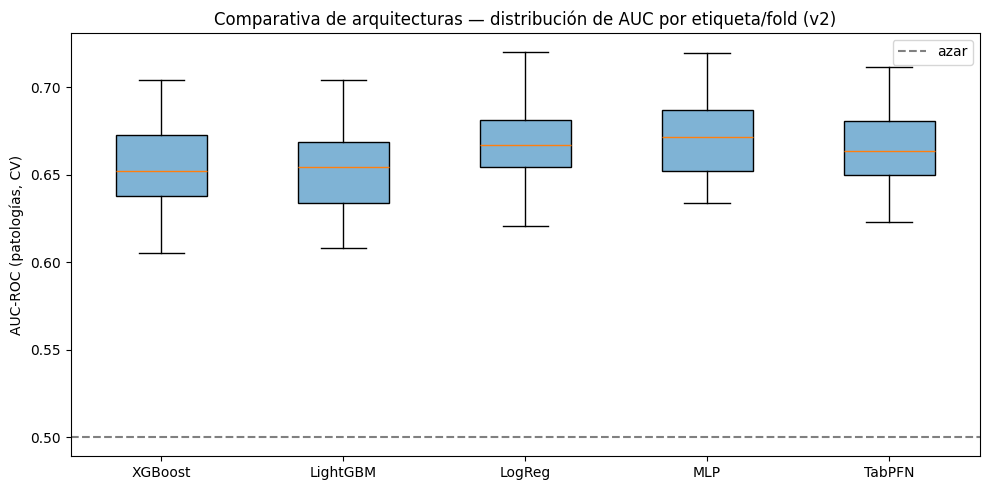

Diagrama de cajas guardado.


In [11]:
# CELDA 11 · TABLA + DIAGRAMA DE CAJAS DE AUC
print(f"{'Modelo':10s} {'macroAUC_path':>16} {'macroAUC_core':>14}")
print("-"*42); rank=[]
for n in MODELS:
    om=multilabel_metrics(oof[n],y_train,m_train)
    print(f"{n:10s} {np.mean(fold_macro[n]):.4f} ± {np.std(fold_macro[n]):.4f}     {om['macro_AUC_core']:.4f}")
    rank.append((n,float(np.mean(fold_macro[n]))))
rank.sort(key=lambda x:-x[1]); BEST_MODEL=rank[0][0]
print(f"\n>>> Mejor arquitectura: {BEST_MODEL} (macroAUC_path={rank[0][1]:.4f})")
fig,ax=plt.subplots(figsize=(10,5))
data=[[a for l in PATHOLOGY_LABELS for a in perlabel_auc[n][l] if not np.isnan(a)] for n in MODELS]
bp=ax.boxplot(data,labels=MODELS,patch_artist=True)
for patch in bp["boxes"]: patch.set_facecolor("#7fb3d5")
ax.axhline(0.5,color="gray",ls="--",label="azar"); ax.set_ylabel("AUC-ROC (patologías, CV)")
ax.set_title("Comparativa de arquitecturas — distribución de AUC por etiqueta/fold (v2)"); ax.legend()
plt.tight_layout(); plt.savefig(FIG_DIR/"boxplot_auc_modelos.png",dpi=150,bbox_inches="tight"); plt.show()
print("Diagrama de cajas guardado.")


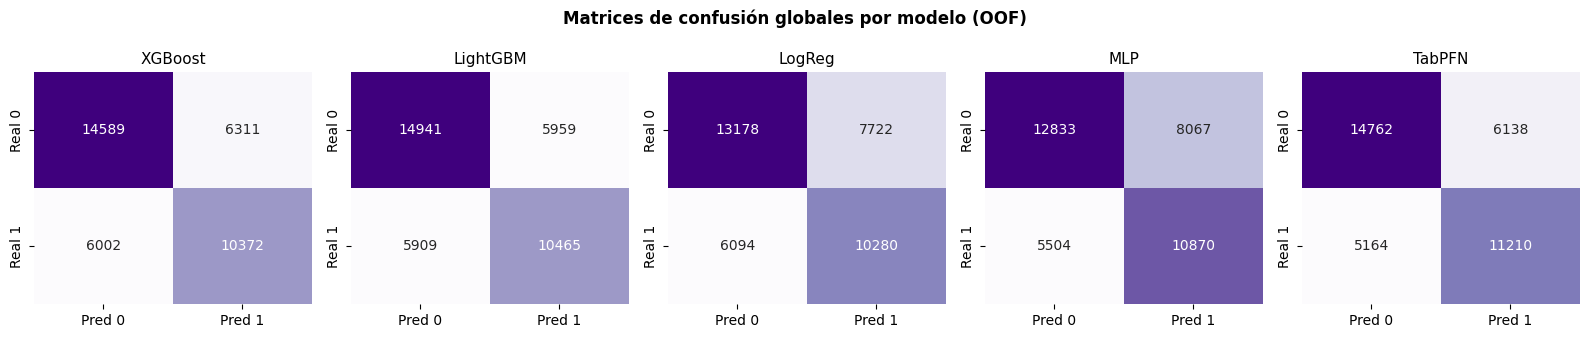

Guardadas.


In [12]:
# CELDA 12 · MATRICES DE CONFUSIÓN POR MODELO (OOF, umbral 0.5)
fig,axes=plt.subplots(1,len(MODELS),figsize=(3.2*len(MODELS),3.4))
if len(MODELS)==1: axes=[axes]
for ax,n in zip(axes,MODELS):
    yt_all=[]; yp_all=[]
    for j in range(N_LABELS):
        s=m_train[:,j]==1; yt_all.append(y_train[s,j]); yp_all.append((oof[n][s,j]>=0.5).astype(int))
    cm=confusion_matrix(np.concatenate(yt_all),np.concatenate(yp_all),labels=[0,1])
    sns.heatmap(cm,annot=True,fmt="d",cmap="Purples",cbar=False,ax=ax,xticklabels=["Pred 0","Pred 1"],yticklabels=["Real 0","Real 1"])
    ax.set_title(n,fontsize=11)
fig.suptitle("Matrices de confusión globales por modelo (OOF)",fontweight="bold")
plt.tight_layout(); plt.savefig(FIG_DIR/"confusion_por_modelo.png",dpi=150,bbox_inches="tight"); plt.show()
print("Guardadas.")


In [13]:
# CELDA 13 · TUNING DEL MEJOR MODELO (Optuna amplio; cada familia su espacio)
def cv_macro(predict_cfg):
    kf=KFold(3,shuffle=True,random_state=SEED); sc=[]
    for tr,va in kf.split(np.arange(len(df_train))):
        imp,scl=dense_fit(tr); Xd_tr=dense_tx(imp,scl,DENSE_tr[tr]); Xd_va=dense_tx(imp,scl,DENSE_tr[va])
        pv=predict_cfg(tr,va,Xd_tr,Xd_va); sc.append(multilabel_metrics(pv,y_train[va],m_train[va])["macro_AUC_path"])
    return float(np.nanmean(sc))
BEST_CFG={}
if BEST_MODEL in ("XGBoost","LightGBM"):
    make=make_xgb if BEST_MODEL=="XGBoost" else make_lgb
    def obj(trial):
        if BEST_MODEL=="XGBoost":
            cfg=dict(n_estimators=trial.suggest_int("n_estimators",400,1500,step=100),max_depth=trial.suggest_int("max_depth",3,9),
                     learning_rate=trial.suggest_float("learning_rate",0.01,0.1,log=True),subsample=trial.suggest_float("subsample",0.6,1.0),
                     colsample_bytree=trial.suggest_float("colsample_bytree",0.5,1.0),min_child_weight=trial.suggest_int("min_child_weight",1,8),
                     reg_lambda=trial.suggest_float("reg_lambda",0.1,8.0,log=True),gamma=trial.suggest_float("gamma",0.0,3.0))
        else:
            cfg=dict(n_estimators=trial.suggest_int("n_estimators",400,1500,step=100),num_leaves=trial.suggest_int("num_leaves",15,255),
                     learning_rate=trial.suggest_float("learning_rate",0.01,0.1,log=True),subsample=trial.suggest_float("subsample",0.6,1.0),
                     colsample_bytree=trial.suggest_float("colsample_bytree",0.5,1.0),min_child_samples=trial.suggest_int("min_child_samples",10,60),
                     reg_lambda=trial.suggest_float("reg_lambda",0.1,8.0,log=True))
        return cv_macro(lambda tr,va,Xd_tr,Xd_va: ovr_fit_predict(lambda spw: make(spw,cfg), TREE_tr[tr], y_train[tr], m_train[tr], TREE_tr[va]))
    study=optuna.create_study(direction="maximize",sampler=optuna.samplers.TPESampler(seed=SEED)); study.optimize(obj,n_trials=OPTUNA_TRIALS_BEST,show_progress_bar=True)
    BEST_CFG=study.best_params; print(f"Mejor config {BEST_MODEL}: {BEST_CFG} (CV={study.best_value:.4f})")
elif BEST_MODEL=="LogReg":
    def obj(trial):
        cfg={"C":trial.suggest_float("C",0.01,10,log=True)}
        return cv_macro(lambda tr,va,Xd_tr,Xd_va: ovr_fit_predict(lambda spw: make_logreg(spw,cfg), Xd_tr, y_train[tr], m_train[tr], Xd_va, use_spw=False))
    study=optuna.create_study(direction="maximize",sampler=optuna.samplers.TPESampler(seed=SEED)); study.optimize(obj,n_trials=min(OPTUNA_TRIALS_BEST,25),show_progress_bar=True)
    BEST_CFG=study.best_params; print(f"Mejor config LogReg: {BEST_CFG} (CV={study.best_value:.4f})")
elif BEST_MODEL=="MLP":
    def obj(trial):
        cfg={"lr":trial.suggest_float("lr",3e-4,3e-3,log=True),"dropout":trial.suggest_float("dropout",0.1,0.5),
             "hidden":trial.suggest_categorical("hidden",[256,512]),"focal":trial.suggest_categorical("focal",[False,True]),
             "wd":trial.suggest_float("wd",1e-5,1e-3,log=True)}
        def pc(tr,va,Xd_tr,Xd_va):
            _,pv=train_mlp(Xd_tr,y_train[tr],m_train[tr],Xd_va,y_train[va],m_train[va],cfg); return pv
        return cv_macro(pc)
    study=optuna.create_study(direction="maximize",sampler=optuna.samplers.TPESampler(seed=SEED)); study.optimize(obj,n_trials=min(OPTUNA_TRIALS_BEST,20),show_progress_bar=True)
    BEST_CFG=study.best_params; print(f"Mejor config MLP: {BEST_CFG} (CV={study.best_value:.4f})")
else:
    print(f"{BEST_MODEL}: sin Optuna; el final usa más contexto y ensembles.")


Best trial: 7. Best value: 0.669484: 100%|██████████| 20/20 [06:17<00:00, 18.88s/it]

Mejor config MLP: {'lr': 0.00045917233096500544, 'dropout': 0.48783385110582345, 'hidden': 512, 'focal': False, 'wd': 0.0006978281265126031} (CV=0.6695)


In [14]:
# CELDA 14 · ENTRENAMIENTO FINAL SERIO (full train, sin leakage) + TEST
imp_f,sc_f=dense_fit(np.arange(len(df_train)))               # imputador+scaler de TODO el train (test nunca lo ve)
Xd_tr_f=dense_tx(imp_f,sc_f,DENSE_tr); Xd_te=dense_tx(imp_f,sc_f,DENSE_te); Xd_vl=dense_tx(imp_f,sc_f,DENSE_vl)
def fit_predict_final(name,cfg):
    if name=="XGBoost": return (ovr_fit_predict(lambda spw: make_xgb(spw,cfg),TREE_tr,y_train,m_train,TREE_te),
                                ovr_fit_predict(lambda spw: make_xgb(spw,cfg),TREE_tr,y_train,m_train,TREE_vl))
    if name=="LightGBM": return (ovr_fit_predict(lambda spw: make_lgb(spw,cfg),TREE_tr,y_train,m_train,TREE_te),
                                 ovr_fit_predict(lambda spw: make_lgb(spw,cfg),TREE_tr,y_train,m_train,TREE_vl))
    if name=="LogReg": return (ovr_fit_predict(lambda spw: make_logreg(spw,cfg),Xd_tr_f,y_train,m_train,Xd_te,use_spw=False),
                               ovr_fit_predict(lambda spw: make_logreg(spw,cfg),Xd_tr_f,y_train,m_train,Xd_vl,use_spw=False))
    if name=="MLP":
        c=dict(cfg) if cfg else {"lr":8e-4,"dropout":0.3}
        mdl,pt=train_mlp(Xd_tr_f,y_train,m_train,Xd_vl,y_val,m_val,c)
        with torch.no_grad():
            mdl.eval(); ptst=torch.sigmoid(mdl(torch.tensor(Xd_te).to(DEVICE))).cpu().numpy()
        return ptst,pt
    if name=="TabPFN":
        # Final más serio: más contexto + más ensembles.
        if len(df_train)<=TABPFN_MAX_FINAL: sub=np.arange(len(df_train))
        else: sub=np.random.RandomState(SEED).choice(len(df_train),TABPFN_MAX_FINAL,replace=False)
        return (ovr_fit_predict(lambda spw: make_tabpfn(spw,8),Xd_tr_f[sub],y_train[sub],m_train[sub],Xd_te,use_spw=False),
                ovr_fit_predict(lambda spw: make_tabpfn(spw,8),Xd_tr_f[sub],y_train[sub],m_train[sub],Xd_vl,use_spw=False))
    raise ValueError(name)
test_pred,val_pred=fit_predict_final(BEST_MODEL,BEST_CFG)
thr_val=best_thresholds_by_f1(val_pred,y_val,m_val); M=multilabel_metrics(test_pred,y_test,m_test,thresholds=thr_val)
print(f"MEJOR MODELO = {BEST_MODEL}")
print(f"{'Etiqueta':18s} {'AUC':>7} {'AP':>7} {'F1':>7} {'Sens':>6} {'Spec':>6} {'N+':>5} {'N-':>5}"); print("-"*74); rows=[]
for l in LABELS:
    m=M[l]; auc=f"{m['AUC']:.4f}" if not np.isnan(m['AUC']) else "  N/A"
    print(f"{l:18s} {auc:>7} {m['AP']:7.4f} {m['F1']:7.4f} {m['sens']:6.3f} {m['spec']:6.3f} {m['n_pos']:5d} {m['n_neg']:5d}")
    rows.append({"label":l,**{k:m[k] for k in ["AUC","AP","F1","sens","spec","n_pos","n_neg"]}})
print("-"*74); print(f"{'MACRO core':18s} {M['macro_AUC_core']:.4f}  ·  MACRO patol. {M['macro_AUC_path']:.4f}")
pd.DataFrame(rows).to_csv(OUTPUT_DIR/"metrics_best_model.csv",index=False)
json.dump({"best_model":BEST_MODEL,"best_config":BEST_CFG,"test_macro_core":M["macro_AUC_core"],
           "test_macro_path":M["macro_AUC_path"],"per_label":{l:M[l] for l in LABELS}},
          open(OUTPUT_DIR/"summary_labs_v2_1.json","w",encoding="utf-8"),indent=2,default=str,ensure_ascii=False)
print("Guardados metrics_best_model.csv y summary_labs_v2_1.json")


MEJOR MODELO = MLP
Etiqueta               AUC      AP      F1   Sens   Spec    N+    N-
--------------------------------------------------------------------------
Atelectasis         0.6745  0.7235  0.7542  0.957  0.137   141    95
Cardiomegaly        0.6046  0.6068  0.6976  0.993  0.061   144   131
Edema               0.7199  0.4768  0.5641  0.805  0.527    82   182
Lung Opacity        0.6824  0.7297  0.7547  0.916  0.272   131    92
No Finding          0.6895  0.3360  0.3464  0.449  0.774    69   349
Pleural Effusion    0.6848  0.6743  0.7002  0.964  0.191   166   162
--------------------------------------------------------------------------
MACRO core         0.6698  ·  MACRO patol. 0.6733
Guardados metrics_best_model.csv y summary_labs_v2_1.json


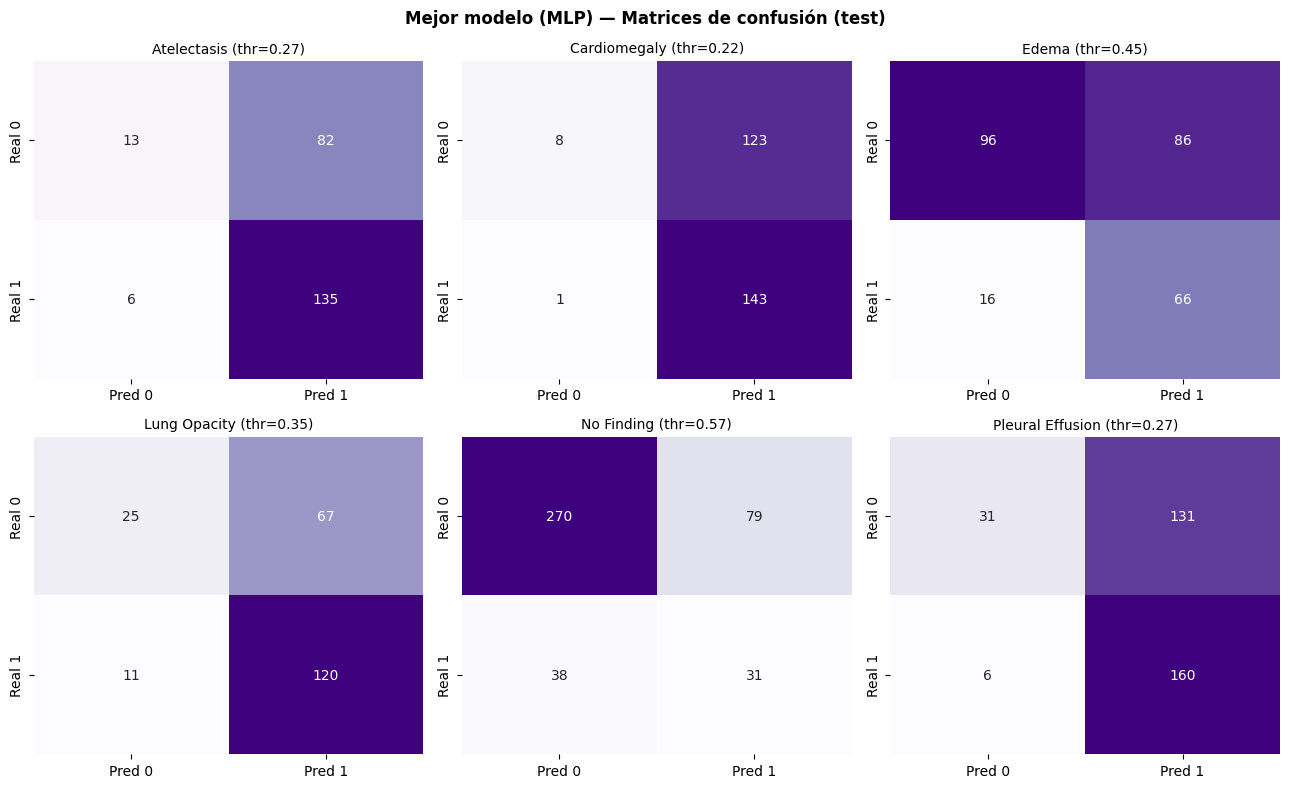

Guardadas.


In [15]:
# CELDA 15 · MATRICES DE CONFUSIÓN DEL MEJOR MODELO (test, por etiqueta)
fig,axes=plt.subplots(2,3,figsize=(13,8)); fig.suptitle(f"Mejor modelo ({BEST_MODEL}) — Matrices de confusión (test)",fontweight="bold")
for j,l in enumerate(LABELS):
    ax=axes[j//3,j%3]; s=m_test[:,j]==1; yt=y_test[s,j]; yp=(test_pred[s,j]>=thr_val.get(l,0.5)).astype(int)
    if len(yt)==0: ax.axis("off"); continue
    cm=confusion_matrix(yt,yp,labels=[0,1])
    sns.heatmap(cm,annot=True,fmt="d",cmap="Purples",cbar=False,ax=ax,xticklabels=["Pred 0","Pred 1"],yticklabels=["Real 0","Real 1"])
    ax.set_title(f"{l} (thr={thr_val.get(l,0.5):.2f})",fontsize=10)
plt.tight_layout(); plt.savefig(FIG_DIR/"confusion_mejor_modelo.png",dpi=150,bbox_inches="tight"); plt.show()
print("Guardadas.")


In [16]:
# CELDA 16 · IMPORTANCIA DE VARIABLES (si el mejor es de árboles) con nombres legibles
if BEST_MODEL in ("XGBoost","LightGBM"):
    make=make_xgb if BEST_MODEL=="XGBoost" else make_lgb
    imp=np.zeros(TREE_tr.shape[1])
    for j in range(N_LABELS):
        sel=m_train[:,j]==1; yj=y_train[sel,j]
        if len(np.unique(yj))<2: continue
        spw=(yj==0).sum()/max((yj==1).sum(),1); clf=make(spw,BEST_CFG); clf.fit(TREE_tr[sel],yj)
        fi=clf.feature_importances_; imp+=fi/(fi.sum()+1e-9)
    imp/=N_LABELS; order=np.argsort(imp)[::-1][:20]
    fig,ax=plt.subplots(figsize=(9,7))
    ax.barh([TREE_NAMES[i] for i in order][::-1],[imp[i] for i in order][::-1],color="#5b8db8")
    ax.set_title(f"Importancia media de variables — {BEST_MODEL} (top 20)"); ax.set_xlabel("importancia (norm.)")
    plt.tight_layout(); plt.savefig(FIG_DIR/"importancia_variables.png",dpi=150,bbox_inches="tight"); plt.show()
    for i in order[:10]: print(f"   {TREE_NAMES[i]:45s} {imp[i]:.4f}")
else:
    print(f"El mejor modelo ({BEST_MODEL}) no es de árboles; la importancia por permutación queda como mejora futura.")


El mejor modelo (MLP) no es de árboles; la importancia por permutación queda como mejora futura.


In [17]:
# CELDA 17 · EQUIDAD POR SUBGRUPO (mejor modelo, test)
dft=df_test.reset_index(drop=True)
for col,lab in [("gender","GÉNERO"),("race","RAZA"),("admission_type","INGRESO")]:
    if col not in dft.columns: continue
    print(f"\n-- AUC macro (patologías) por {lab} --")
    for v in sorted(dft[col].dropna().unique(),key=str):
        idx=dft.index[dft[col]==v].to_numpy()
        if len(idx)<15: print(f"   {str(v):22s} n={len(idx):4d} (insuficiente)"); continue
        mm=multilabel_metrics(test_pred[idx],y_test[idx],m_test[idx]); print(f"   {str(v):22s} n={len(idx):4d}  macroAUC_path={mm['macro_AUC_path']:.4f}")
print("\nEquidad completada.")



-- AUC macro (patologías) por GÉNERO --
   0                      n= 184  macroAUC_path=0.6495
   1                      n= 280  macroAUC_path=0.6850

-- AUC macro (patologías) por RAZA --
   ASIAN                  n=  15  macroAUC_path=0.7608
   BLACK                  n=  58  macroAUC_path=0.5970
   HISPANIC_LATINO        n=  21  macroAUC_path=0.5992
   OTHER_KNOWN            n=   3 (insuficiente)
   UNKNOWN                n=  52  macroAUC_path=0.5717
   WHITE                  n= 315  macroAUC_path=0.7036

-- AUC macro (patologías) por INGRESO --
   EMERGENCY              n= 322  macroAUC_path=0.6296
   OBSERVATION            n=  66  macroAUC_path=0.7758
   SCHEDULED              n=  34  macroAUC_path=0.5467
   URGENT                 n=  42  macroAUC_path=0.7179

Equidad completada.


---
## ✅ Conclusión — Módulo tabular v2.1

Versión más completa: **K=5**, **MLP profundo**, **Optuna amplio**, **TabPFN con más contexto/ensembles**, y sobre todo
**imputación/escalado por fold (sin data leakage)** y **sin `cxr_view`**. Mantiene raw/percentil por familia de modelo,
flags de missingness (MNAR), enmascarado + negativos derivados de *No Finding*, y corrección de desequilibrio por etiqueta.
**AUC-ROC macro** es la métrica principal. Modelo **independiente** (sin fusión).
